## Project : 1 - Retail Sales Analysis

In [129]:
## Importing all Essential Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
## Loading Dataset
data_path = "E:\Project-1\Data\online_retail_II (Raw).csv"
df = pd.read_csv(data_path)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [131]:
## Checking rows and columns
print(df.shape)
print()

## Checking datatypes
print(df.info())

(1067371, 8)

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB
None


In [132]:
## Checking duplicates values
df.duplicated().sum()

## Removing Duplicate rows
df = df.drop_duplicates()

In [133]:
## Total Rows and columns
df.shape

(1033036, 8)

In [134]:
## Checking NULL values
df.isnull().sum()

Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64

In [135]:
## Checking Missing Values in Percentage
df.isnull().mean() * 100

Invoice         0.000000
StockCode       0.000000
Description     0.413829
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.763098
Country         0.000000
dtype: float64

In [136]:
# Changing Datatype of "InvoiceDate"
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

## Extracting Important Columns from Invoice Date
df["Year"] = df["InvoiceDate"].dt.year
df["Hour"] = df["InvoiceDate"].dt.hour
df["Day"] = df["InvoiceDate"].dt.day_name()
df["YearMonth"] = df["InvoiceDate"].dt.to_period('M').astype(str)

print(df[["InvoiceDate", "Year", "Day", "Hour", "YearMonth"]].head())

          InvoiceDate  Year      Day  Hour YearMonth
0 2009-12-01 07:45:00  2009  Tuesday     7   2009-12
1 2009-12-01 07:45:00  2009  Tuesday     7   2009-12
2 2009-12-01 07:45:00  2009  Tuesday     7   2009-12
3 2009-12-01 07:45:00  2009  Tuesday     7   2009-12
4 2009-12-01 07:45:00  2009  Tuesday     7   2009-12


In [137]:
## Handling Missing Values in "Description"
df["Description"] = df["Description"].fillna("Unknown")     # Fill with "unkonwn"

In [138]:
## Checking Customer ID Column, Before Filling Dataset
print(f"Total Customers : {df['Customer ID'].count()}")
print(f"Unique Customers : {len(df['Customer ID'].unique())}")

Total Customers : 797885
Unique Customers : 5943


In [139]:
## Handling missing values in "Customer ID"
df["Customer ID"] = df["Customer ID"].fillna(-1)    # Fill null values with (-1)

## Changing Dataypes of "Customer ID"
df["Customer ID"] = df["Customer ID"].astype(int)

## Creating New Coloumn (Is_guest)
df["Is_guest"] = np.where(df["Customer ID"] == -1, "Yes", "No")

In [140]:
df["Is_guest"].value_counts()

Is_guest
No     797885
Yes    235151
Name: count, dtype: int64

##### "Quantity" Column Analysis 

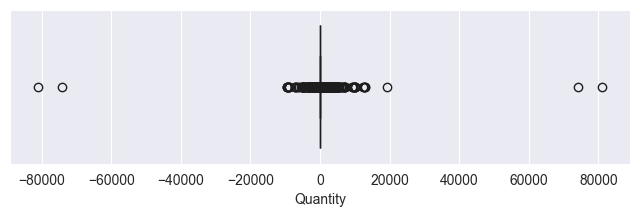

In [141]:
## Checking Outliers in Quantity
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Quantity"])
plt.show()

In [142]:
## Checking Return or Cancelled Products 
print(f"Total Returned or Cancelled Order : {len(df[df['Quantity'] < 0])}")


## Creating New Coloumn "Order_Status"
df["Order Status"] = np.where(df["Quantity"] > 0, "Completed", "Returned / Cancelled")

Total Returned or Cancelled Order : 22496


In [143]:
df["Order Status"].value_counts()

Order Status
Completed               1010540
Returned / Cancelled      22496
Name: count, dtype: int64

In [144]:
## Outlier Handling (Capping)
q_upper_limit = df["Quantity"].quantile(0.99)

## Upper limit and Lower Limit Capping
df["Quantity"] = df["Quantity"].clip(lower=0, upper=q_upper_limit)

print(f"New Max Quantity: {df['Quantity'].max()}")

New Max Quantity: 108


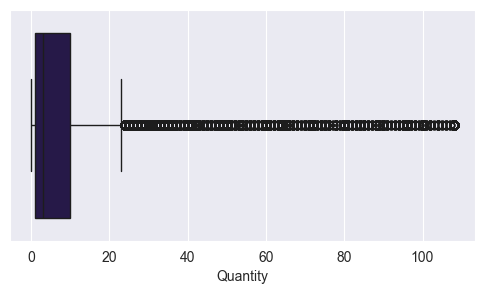

In [145]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df["Quantity"])
plt.show()

##### "Price" Column Analysis

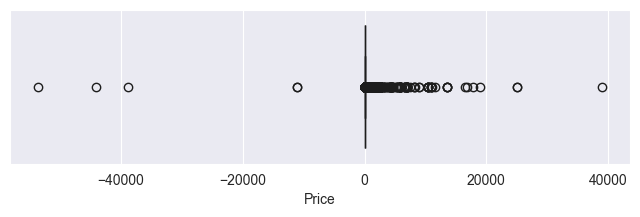

In [146]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Price"])
plt.show()

In [147]:
p_limit = df["Price"].quantile(0.99)
print(f"99% Products are under price: {p_limit}")

# Capping on lower and upper limit
df["Price"] = df["Price"].clip(lower=0.1, upper=p_limit)


99% Products are under price: 18.0


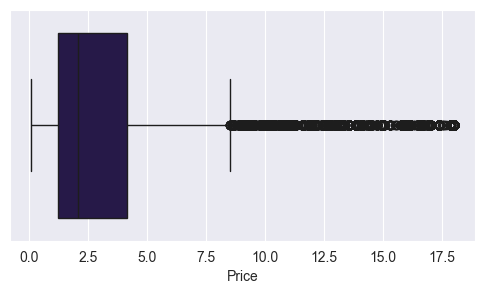

In [148]:
## Now, Cleaned Price Column
plt.figure(figsize=(6,3))
sns.boxplot(x=df["Price"])
plt.show()

In [149]:
## Creating New "Total Sales" Column
df["Total Sales"] = df["Quantity"] * df["Price"]
df.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Hour,Day,YearMonth,Is_guest,Order Status,Total Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009,7,Tuesday,2009-12,No,Completed,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,7,Tuesday,2009-12,No,Completed,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,7,Tuesday,2009-12,No,Completed,81.0


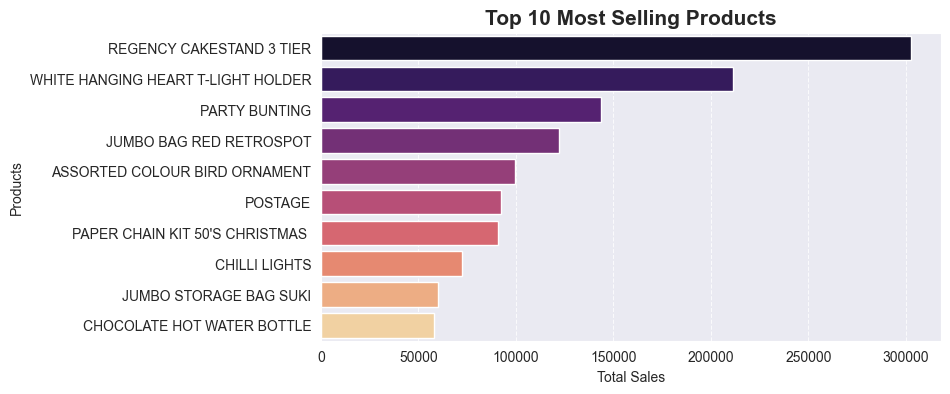

In [168]:
## Top 10 Most Selling Products (Only Genuine Orders)
completed_orders = df[df["Order Status"] == "Completed"]
top_10 = completed_orders.groupby("Description")["Total Sales"].sum().sort_values(ascending=False).head(10)
top_10_df = top_10.reset_index()


sns.set_palette("magma")
sns.set_style("darkgrid")
plt.figure(figsize=(8,4))
sns.barplot(x="Total Sales", y="Description", data=top_10_df, palette="magma", hue="Description")
plt.title("Top 10 Most Selling Products", fontsize=15, fontweight='bold')
plt.grid(alpha =0.8, axis="x", linestyle = "--")
plt.xlabel("Total Sales")
plt.ylabel("Products")
plt.show()

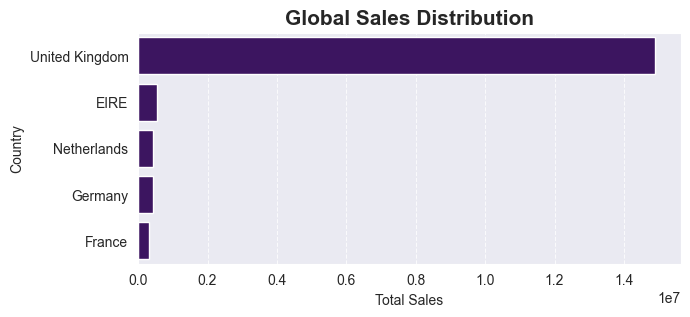

In [151]:
## GLobally Sales (Top Sales Countries)
completed_orders = df[df["Order Status"] == "Completed"]
Country = completed_orders.groupby("Country")["Total Sales"].sum().sort_values(ascending=False).head(5)
df_country = Country.reset_index()


sns.set_style("darkgrid")
plt.figure(figsize=(7,3))
sns.barplot(x="Total Sales", y="Country", data= df_country, color="#3c096c")
plt.title("Global Sales Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.grid(alpha =0.8, axis="x", linestyle = "--")
plt.show()

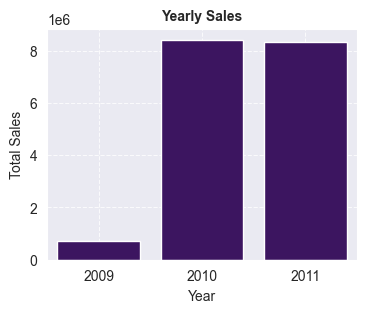

In [152]:
## Yearly Sales
yearly_sales = completed_orders.groupby("Year")["Total Sales"].sum().reset_index()

sns.set_style("darkgrid")
plt.figure(figsize=(4,3))
sns.barplot(x="Year", y="Total Sales", data= yearly_sales, color="#3c096c")
plt.title("Yearly Sales", fontsize=10, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(alpha =0.8, linestyle = "--")
plt.show()


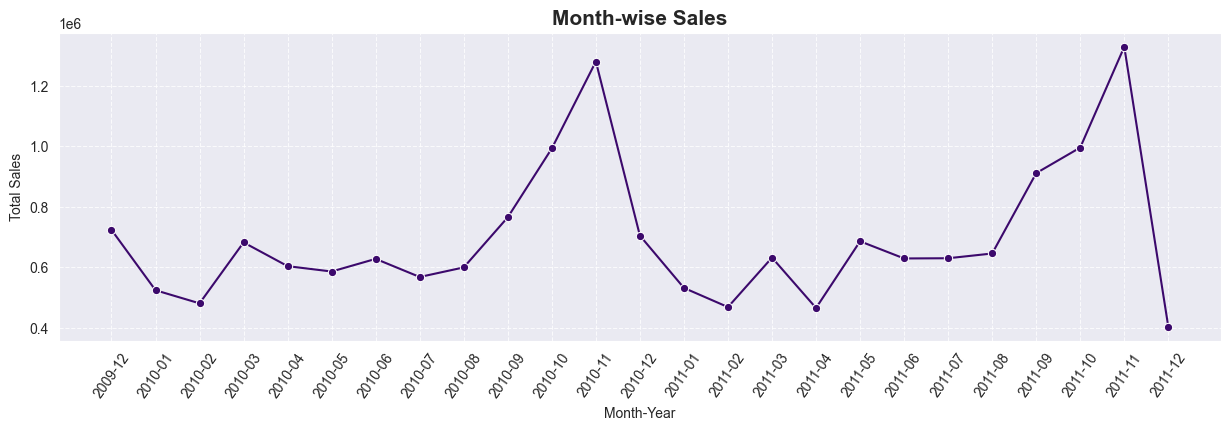

In [188]:
## Monthly Sales
completed_orders = df[df["Order Status"] == "Completed"]
monthly_sales = completed_orders.groupby("YearMonth")["Total Sales"].sum().reset_index()


sns.set_style("darkgrid")
plt.figure(figsize=(15,4))
sns.lineplot(x="YearMonth", y="Total Sales", data= monthly_sales, color= "#3c096c", marker="o")
plt.title("Month-wise Sales", fontsize=15, fontweight='bold')
plt.xlabel("Month-Year")
plt.ylabel("Total Sales")
plt.xticks(rotation=55)
plt.grid(alpha =0.8, linestyle = "--")
plt.show()

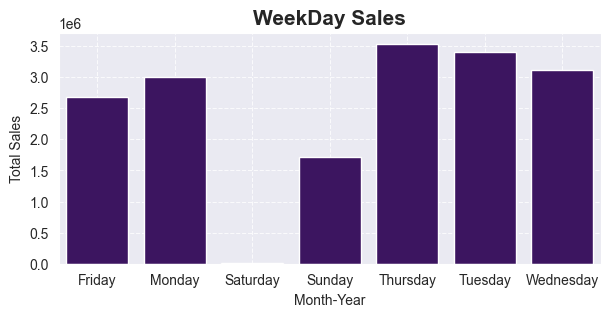

In [154]:
## Weekday Sales
completed_orders = df[df["Order Status"] == "Completed"]
day_sales = completed_orders.groupby("Day")["Total Sales"].sum().reset_index()


sns.set_style("darkgrid")
plt.figure(figsize=(7,3))
sns.barplot(x="Day", y="Total Sales", data= day_sales, color="#3c096c")
plt.title("WeekDay Sales", fontsize=15, fontweight='bold')
plt.xlabel("Month-Year")
plt.ylabel("Total Sales")
plt.grid(alpha =0.8, linestyle = "--")
plt.show()

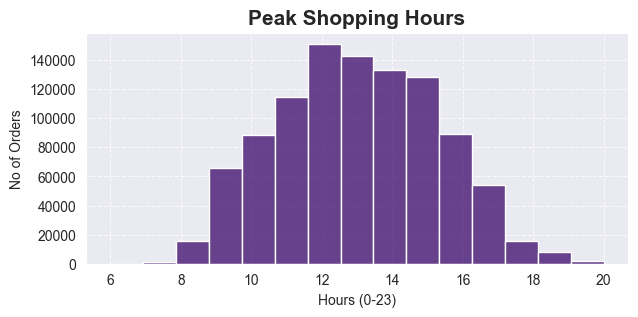

In [155]:
## Peak Sales Hours
completed_orders = df[df["Order Status"] == "Completed"]

sns.set_style("darkgrid")
plt.figure(figsize=(7,3))
sns.histplot(completed_orders["Hour"], bins=15, color="#3c096c")
plt.title("Peak Shopping Hours", fontsize=15, fontweight='bold')
plt.xlabel("Hours (0-23)")
plt.ylabel("No of Orders")
plt.grid(alpha =0.8, linestyle = "--")
plt.show()

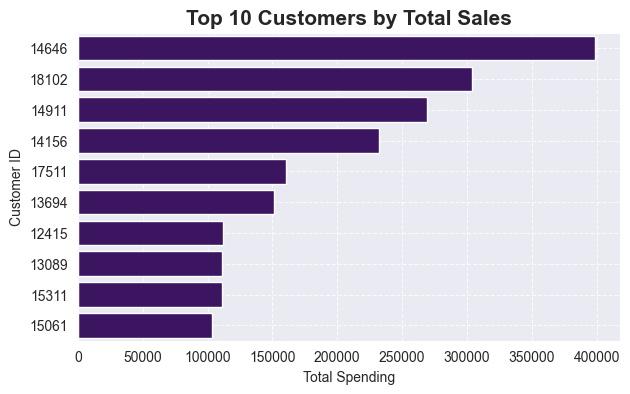

In [176]:
## Top 10 Customers
valid_customer = completed_orders[completed_orders["Customer ID"] != -1]    ## Guest Customers
top_customers = valid_customer.groupby("Customer ID")["Total Sales"].sum().sort_values(ascending=False).head(10)
top_customers_df = top_customers.reset_index()


plt.figure(figsize=(7, 4))
sns.barplot(data=top_customers_df, x="Total Sales", y=top_customers_df["Customer ID"].astype(str), 
            color="#3c096c", legend=False)

plt.title("Top 10 Customers by Total Sales", fontsize=15, fontweight='bold')
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")
plt.grid(alpha =0.8, linestyle = "--")
plt.show()

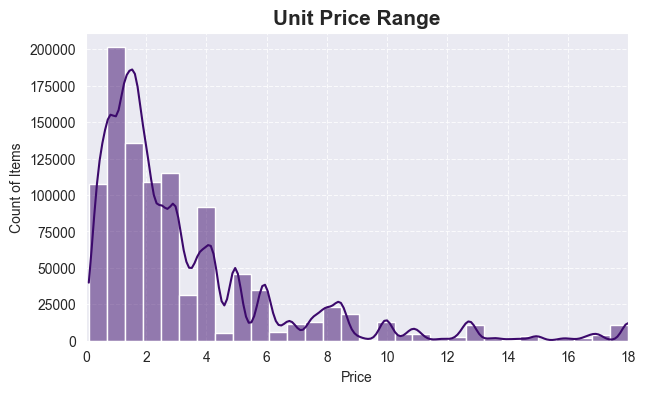

In [157]:
## Unit Price Checking
completed_orders = df[df["Order Status"] == "Completed"]

sns.set_style("darkgrid")
plt.figure(figsize=(7,4))
sns.histplot(x="Price", data=completed_orders, bins=30, color="#3c096c", kde=True)
plt.xlim(0,18)
plt.title("Unit Price Range", fontsize=15, fontweight='bold')
plt.xlabel("Price")
plt.ylabel("Count of Items")
plt.grid(alpha =0.8, linestyle = "--")
plt.show()

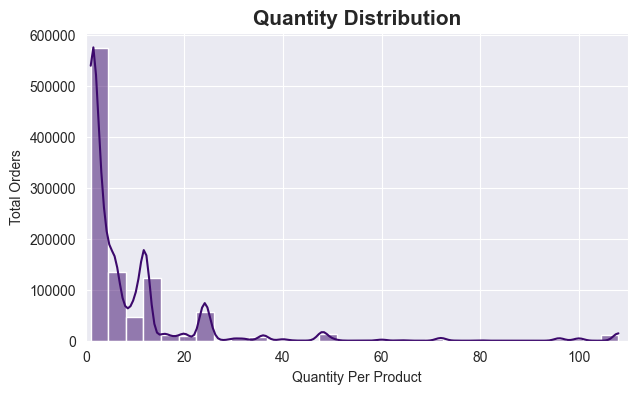

In [158]:
## Quantity Distribution
completed_orders = df[df["Order Status"] == "Completed"]

sns.set_style("darkgrid")
plt.figure(figsize=(7, 4))
sns.histplot(data=completed_orders, x="Quantity", bins= 30, color="#3c096c", kde=True)
plt.xlim(0,110)
plt.title("Quantity Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Quantity Per Product")
plt.ylabel("Total Orders")
plt.show()

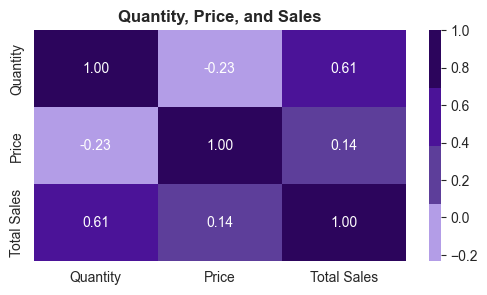

In [178]:
## Corelation B/w Price, Quantity and Total Sales
numerical_cols = completed_orders[["Quantity", "Price", "Total Sales"]]
corr_matrix = numerical_cols.corr()

purple_shades = ["#B39DE7", "#5D3E9A", "#4B1398", "#2C055C"]
sns.set_style("darkgrid")
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True, cmap=purple_shades, fmt=".2f", linecolor='white')
plt.title("Quantity, Price, and Sales", fontsize=12, fontweight='bold')
plt.show()

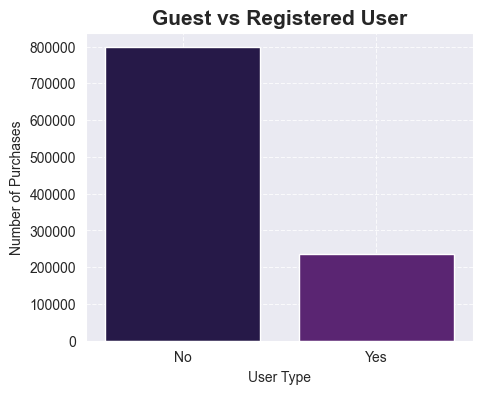

In [160]:
## Guest vs Registered Users
sns.set_style("darkgrid")
plt.figure(figsize=(5,4))
sns.countplot(data=df, x= "Is_guest", hue="Is_guest", legend=False)
plt.title("Guest vs Registered User", fontsize=15, fontweight='bold')
plt.ylabel("Number of Purchases")
plt.xlabel("User Type")
plt.grid(alpha =0.8, linestyle = "--")
plt.show()

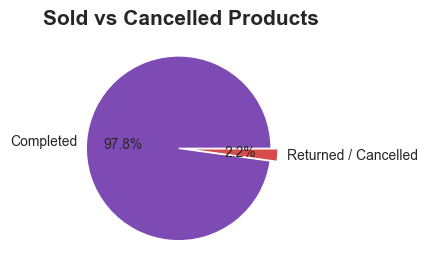

In [185]:
## Cancelled vs Sold Products
status_count = df["Order Status"].value_counts()
colors = ["#7e4bb4", "#d74b4b"]

plt.figure(figsize=(5,3))
plt.pie(status_count, labels=status_count.index, autopct="%1.1f%%", colors=colors, explode=(0.025, 0.05))
plt.title("Sold vs Cancelled Products", fontsize=15, fontweight='bold')
plt.show()


In [162]:
## Average Order Value
completed_orders = df[df["Order Status"] == "Completed"]
total_orders = completed_orders.groupby("Invoice")["Total Sales"].sum()
avr_ord_val = float(total_orders.mean())
print(f"Average Order Value : {avr_ord_val:.2f}")

Average Order Value : 416.44


In [163]:
## Total Sales
print(f"Total Sales from (12-2009 to 12-2011) : {sum(completed_orders['Total Sales']):.3f}")

Total Sales from (12-2009 to 12-2011) : 17467309.340


In [164]:
## Average Order Quantity
total_Quantity = completed_orders.groupby("Invoice")["Quantity"].sum()
avr_ord_qnt = float(total_Quantity.mean())
print(f"Average Order Quantity : {avr_ord_qnt:.2f}")
print(f"Average Order Quantity as (Median) : {total_Quantity.median()}")

Average Order Quantity : 217.42
Average Order Quantity as (Median) : 132.0


### Business Insights --

(1)  Applied 99th percentile capping on Quantity and Price to handle outliers and clean the data. 
   
(2)  Achieved a total revenue £1.74 Crore with the UK as the primary market.  
  
(3) Observed a massive sales surge during the Q4 peak season (Sept-Nov) due to Christmas Festive season.  
  
(4) Identified Tuesday and Thursday as the most active days, while weekends shows slow Business.  
  
(5) Peak customers Shopping traffic, daily between 12:00 PM and 3:00 PM.  
  
(6) Strong brand loyalty shows with 80% are Registered members while 20% are Guest users.  
  
(7) Discovered that Majority of top-selling products are budget-friendly, ranging from £0.1 to £4.  
  
(8) Typical order behavior shows a (Average) Median Quantity of 132 units and an Average Order Value (AOV) of £416. 
   
(9) Data is Right-Skewed Distribution, where most customers prefer small quantities (0-10 units).  
  
(10) Very Good operational flow with only 3% Cancellation/Return rate and 97% Orders are Fulfilled.  
  
(11) Identified Top 10 Loyal Customers for future VIP rewards and retention strategies.  

NOTE :- All business insights are strictly achieved on Completed/Sold orders to ensure data accuracy.